# Downsampling

In [4]:
import pandas as pd
import numpy as np


In [5]:
data= pd.read_csv("emotions.csv")

In [6]:
df_sampled = (
    data.groupby("label", group_keys=False)
      .apply(lambda x: x.sample(n=200, replace=False, random_state = 42))
      .sample(frac=1, random_state=42)   # optional: shuffle all groups together
).reset_index(drop = True)

In [7]:
df_train = df_sampled.iloc[:1000, :]
df_test = df_sampled.iloc[1000:, :]

In [8]:
df_train.to_csv("train_sentiment.csv", index = False)
df_test.to_csv("test_sentiment.csv", index = False)

# Generations

In [1]:
import pandas as pd
import numpy as np
data_train = pd.read_csv("train_sentiment.csv") # read data
n = data_train.shape[0]
print(n)

1000


In [2]:
label_map = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}

# Apply mapping
data_train["emotion"] = data_train["label"].map(label_map)

print(data_train.head)

<bound method NDFrame.head of                                                   text  label   emotion
0    i only played the london mission from the demo...      5  surprise
1    i am feeling fearful confused a deep and profo...      4      fear
2    i go overboard with my sense of duty and respo...      0   sadness
3    i feel most passionate about and currently thi...      2      love
4    i feel almost embarrassed to be writing its be...      0   sadness
..                                                 ...    ...       ...
995  i started feeling super nauseous since im real...      1       joy
996  i hate feeling envious and i see it as an alar...      3     anger
997  im not quite so animated but its just a way of...      1       joy
998  i am feeling very apprehensive i know it isnt ...      4      fear
999     ive been feeling amorous which also kept me up      2      love

[1000 rows x 3 columns]>


In [3]:
emo_ls = ", ".join(data_train["emotion"].drop_duplicates())
emo_ls

'surprise, fear, sadness, love, joy, anger'

In [5]:
import time
import random
import concurrent.futures
import re
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type
import openai
from openai import OpenAI

client = OpenAI(api_key="...")

class RateLimitException(Exception):
    pass

@retry(
    retry=retry_if_exception_type(RateLimitException),
    wait=wait_exponential(multiplier=1, min=1, max=60),
    stop=stop_after_attempt(15)
)
def call_openai_api(client, prompt, n=20):
    try:
        response = client.chat.completions.create(
            model="gpt-4.1-nano",
            messages=[{"role": "user", "content": prompt}],
            n=n,
            temperature=1.5
        )
        return response
    except Exception as e:
        error_message = str(e).lower()
        if "rate limit" in error_message or "429" in error_message:
            wait_time_match = re.search(r'try again in (\d+)ms', error_message)
            if wait_time_match:
                wait_ms = int(wait_time_match.group(1))
                wait_time = (wait_ms / 1000) + random.uniform(0.1, 0.5)
            else:
                wait_time = random.uniform(1, 3)

            print(f"Rate limit hit. Waiting for {wait_time:.2f} seconds before retry...")
            time.sleep(wait_time)
            raise RateLimitException("Rate limit exceeded")
        else:
            raise

import re

def count_sentences(text: str) -> list[str]:
    """
    Split text into sentences conservatively.
    Returns a list of non-empty sentences.
    """
    # Split on ., ?, ! followed by space/newline or end of string
    parts = re.split(r'(?<=[.!?])\s+(?=[A-Z0-9(])|(?<=[.!?])$', text.strip())
    # Clean up stray empties/whitespace
    sents = [s.strip() for s in parts if s and s.strip()]
    return sents

def process_item(client, idx, sentences):
    tweet = sentences[0]
    base_prompt = (
        "You are given a short Twitter message.\n\n"
        f"Message: {tweet}\n\n"
        "Task: Extend the message by writing additional content that keeps the SAME sentiment and topic consistent.\n"
        "- Write EXACTLY 5 sentences.\n"
        "- Paraphrase and expand naturally; do not reuse wording from the original.\n"
        "- Introduce diversity in phrasing, tone, and detail while staying aligned with the sentiment.\n"
        "- Avoid lists, bullets, hashtags, mentions, links, or numbering; just 5 full sentences in a single paragraph.\n"
        "- No disclaimers, no citations, no markdown.\n"
    )

    max_attempts = 20
    while max_attempts > 0:
        try:
            response = call_openai_api(client, base_prompt, n=1)
            content = response.choices[0].message.content.strip()
            sents = count_sentences(content)

            if len(sents) == 5:
                # Return clean paragraph
                return sents
            else:
                # Not exactly 10 → retry
                max_attempts -= 1
        except Exception:
            max_attempts -= 1

    print(f"Warning: Could not get exactly 5 sentences for item {idx}")
    return None

def process_with_rate_limiting(client, input_texts, max_concurrent=5, batch_size=20):
    all_responses = []

    for batch_start in range(0, len(input_texts), batch_size):
        batch_end = min(batch_start + batch_size, len(input_texts))
        batch = input_texts[batch_start:batch_end]

        print(f"Processing batch {batch_start // batch_size + 1}, items {batch_start} to {batch_end - 1}")

        with concurrent.futures.ThreadPoolExecutor(max_workers=max_concurrent) as executor:
            futures = [
                executor.submit(process_item, client, idx + batch_start, sentences)
                for idx, sentences in enumerate(batch)
            ]

            # Ensure order of responses matches order of input_texts
            batch_results = [future.result() for future in futures]

        all_responses.extend(batch_results)

        if batch_end < len(input_texts):
            wait_time = random.uniform(1, 3)
            time.sleep(wait_time)

    return all_responses

In [7]:
pairs = []
for i in range(data_train.shape[0]):
    pairs.append((data_train["text"].iloc[i], data_train["emotion"].iloc[i]))

In [9]:
generations = process_with_rate_limiting(client, pairs)


Processing batch 1, items 0 to 19
Processing batch 2, items 20 to 39
Processing batch 3, items 40 to 59
Processing batch 4, items 60 to 79
Processing batch 5, items 80 to 99
Processing batch 6, items 100 to 119
Processing batch 7, items 120 to 139
Processing batch 8, items 140 to 159
Processing batch 9, items 160 to 179
Processing batch 10, items 180 to 199
Processing batch 11, items 200 to 219
Processing batch 12, items 220 to 239
Processing batch 13, items 240 to 259
Processing batch 14, items 260 to 279
Processing batch 15, items 280 to 299
Processing batch 16, items 300 to 319
Processing batch 17, items 320 to 339
Processing batch 18, items 340 to 359
Processing batch 19, items 360 to 379
Processing batch 20, items 380 to 399
Processing batch 21, items 400 to 419
Processing batch 22, items 420 to 439
Processing batch 23, items 440 to 459
Processing batch 24, items 460 to 479
Processing batch 25, items 480 to 499
Processing batch 26, items 500 to 519
Processing batch 27, items 520 t

In [10]:
import pickle

with open("generations_sentiment.pickle", "wb") as file:
    pickle.dump(generations, file)

# Gemini as Judge

In [17]:
import google.generativeai as genai
import os
import time
from dotenv import load_dotenv

# Load environment variables
load_dotenv()
genai.configure(api_key=os.getenv("GOOGLE_API_KEY"))

model = genai.GenerativeModel("gemini-2.5-flash")

def batch_eval(all_pairs, disease_ls, batch_size=20, max_retries=5, sleep_time=2, save_every=25, save_path="scores_checkpoint.csv"):
    all_scores = []
    batch_counter = 0  # track how many batches processed

    for start in range(0, all_pairs.shape[0], batch_size):
        end = min(start + batch_size, all_pairs.shape[0])
        batch = all_pairs.iloc[start:end]

        # Build base prompt
# Build base prompt
        prompt = (
            "You are evaluating individual sentences for sentiment consistency.\n\n"
            "Scoring instructions:\n"
            "- Assign each sentence a score between 0 and 1, rounded to two decimal places.\n"
            "- Criteria: The sentence should clearly express the SPECIFIED sentiment, remain coherent, and avoid conflicting or opposite emotions.\n"
            "- Use the full 0–1 range: 1 = perfectly consistent with the sentiment and natural; 0 = completely unusable.\n"
            "- 0.5 is the threshold: any sentence with a score ≤ 0.5 should be dropped to prevent sentiment drift.\n\n"
            "Output requirements:\n"
            "- Output only the scores, one per line, in the same order as the input cases.\n"
            "- Do not include explanations, text, or formatting other than the numeric scores.\n\n"
        )

        for i, row in batch.iterrows():
            sent, senti = row["sentence"], row["sentiment"]
            prompt += f"Case {i}:\nSentiment: {senti}\nSentence: {sent}\n"

        # Retry loop
        scores = []
        for attempt in range(1, max_retries + 1):
            try:
                response = model.generate_content(prompt)
                scores = response.text.strip().splitlines()

                if len(scores) == len(batch):
                    break  # ✅ got the right number of outputs
                else:
                    print(
                        f"⚠️ Attempt {attempt}: Expected {len(batch)} scores, got {len(scores)}. Retrying..."
                    )
                    time.sleep(sleep_time)

            except Exception as e:
                print(f"❌ Error on attempt {attempt}: {e}")
                time.sleep(sleep_time)

        if len(scores) != len(batch):
            raise ValueError(
                f"Failed after {max_retries} retries: Expected {len(batch)} scores, got {len(scores)}"
            )

        all_scores.extend(scores)
        batch_counter += 1
        print(f"✅ Processed {end}/{all_pairs.shape[0]}")

        if batch_counter % save_every == 0:
            pd.DataFrame({"score": all_scores}).to_csv(save_path, index=False)
            print(f"💾 Saved checkpoint after {batch_counter} batches at {save_path}")

    pd.DataFrame({"score": all_scores}).to_csv(save_path, index=False)
    print(f"🎉 Finished. Final results saved at {save_path}")

    return all_scores

In [18]:

import pickle
with open("generations_sentiment.pickle", "rb") as file:
    generations = pickle.load(file)

all_rows = []

# 2. Loop through the augmented data.
for i in range(data_train.shape[0]):
    output_text = data_train["emotion"].iloc[i]

    # Add the original row
    for j in generations[i]:
        all_rows.append([j, output_text])



# 4. Create the DataFrame from the list in one single, efficient operation.
df = pd.DataFrame(all_rows, columns=["sentence", "sentiment"])

In [26]:
scores = batch_eval(df, emo_ls, batch_size=10, save_path="scores_flash_sentiment.csv", save_every = 10)

✅ Processed 10/4900
✅ Processed 20/4900
✅ Processed 30/4900
✅ Processed 40/4900
✅ Processed 50/4900
✅ Processed 60/4900
✅ Processed 70/4900
✅ Processed 80/4900
✅ Processed 90/4900
✅ Processed 100/4900
💾 Saved checkpoint after 10 batches at scores_flash_sentiment.csv
✅ Processed 110/4900
✅ Processed 120/4900
✅ Processed 130/4900
✅ Processed 140/4900
✅ Processed 150/4900
✅ Processed 160/4900
✅ Processed 170/4900
✅ Processed 180/4900
✅ Processed 190/4900
✅ Processed 200/4900
💾 Saved checkpoint after 20 batches at scores_flash_sentiment.csv
✅ Processed 210/4900
✅ Processed 220/4900
✅ Processed 230/4900
✅ Processed 240/4900
✅ Processed 250/4900
✅ Processed 260/4900
✅ Processed 270/4900
✅ Processed 280/4900
✅ Processed 290/4900
✅ Processed 300/4900
💾 Saved checkpoint after 30 batches at scores_flash_sentiment.csv
✅ Processed 310/4900
✅ Processed 320/4900
✅ Processed 330/4900
✅ Processed 340/4900
✅ Processed 350/4900
✅ Processed 360/4900
✅ Processed 370/4900
✅ Processed 380/4900
✅ Processed 3

In [27]:
import google.generativeai as genai
import os
import time
from dotenv import load_dotenv

# Load environment variables
load_dotenv()
genai.configure(api_key=os.getenv("GOOGLE_API_KEY"))

model = genai.GenerativeModel("gemini-2.5-pro")

def batch_eval(all_pairs, disease_ls, batch_size=20, max_retries=5, sleep_time=2, save_every=25, save_path="scores_checkpoint.csv"):
    all_scores = []
    batch_counter = 0  # track how many batches processed

    for start in range(0, all_pairs.shape[0], batch_size):
        end = min(start + batch_size, all_pairs.shape[0])
        batch = all_pairs.iloc[start:end]

        # Build base prompt
# Build base prompt
        prompt = (
            "You are evaluating individual sentences for sentiment consistency.\n\n"
            "Scoring instructions:\n"
            "- Assign each sentence a score between 0 and 1, rounded to two decimal places.\n"
            "- Criteria: The sentence should clearly express the SPECIFIED sentiment, remain coherent, and avoid conflicting or opposite emotions.\n"
            "- Use the full 0–1 range: 1 = perfectly consistent with the sentiment and natural; 0 = completely unusable.\n"
            "- 0.5 is the threshold: any sentence with a score ≤ 0.5 should be dropped to prevent sentiment drift.\n\n"
            "Output requirements:\n"
            "- Output only the scores, one per line, in the same order as the input cases.\n"
            "- Do not include explanations, text, or formatting other than the numeric scores.\n\n"
        )

        for i, row in batch.iterrows():
            sent, senti = row["sentence"], row["sentiment"]
            prompt += f"Case {i}:\nSentiment: {senti}\nSentence: {sent}\n"

        # Retry loop
        scores = []
        for attempt in range(1, max_retries + 1):
            try:
                response = model.generate_content(prompt)
                scores = response.text.strip().splitlines()

                if len(scores) == len(batch):
                    break  # ✅ got the right number of outputs
                else:
                    print(
                        f"⚠️ Attempt {attempt}: Expected {len(batch)} scores, got {len(scores)}. Retrying..."
                    )
                    time.sleep(sleep_time)

            except Exception as e:
                print(f"❌ Error on attempt {attempt}: {e}")
                time.sleep(sleep_time)

        if len(scores) != len(batch):
            raise ValueError(
                f"Failed after {max_retries} retries: Expected {len(batch)} scores, got {len(scores)}"
            )

        all_scores.extend(scores)
        batch_counter += 1
        print(f"✅ Processed {end}/{all_pairs.shape[0]}")

        if batch_counter % save_every == 0:
            pd.DataFrame({"score": all_scores}).to_csv(save_path, index=False)
            print(f"💾 Saved checkpoint after {batch_counter} batches at {save_path}")

    pd.DataFrame({"score": all_scores}).to_csv(save_path, index=False)
    print(f"🎉 Finished. Final results saved at {save_path}")

    return all_scores

In [28]:
scores = batch_eval(df, emo_ls, batch_size=10, save_path="scores_pro_sentiment.csv", save_every = 10)

✅ Processed 10/500
✅ Processed 20/500
✅ Processed 30/500
✅ Processed 40/500
✅ Processed 50/500
✅ Processed 60/500
✅ Processed 70/500
✅ Processed 80/500
✅ Processed 90/500
✅ Processed 100/500
💾 Saved checkpoint after 10 batches at scores_pro_sentiment.csv
✅ Processed 110/500
✅ Processed 120/500
✅ Processed 130/500
✅ Processed 140/500
✅ Processed 150/500
✅ Processed 160/500
✅ Processed 170/500
✅ Processed 180/500
✅ Processed 190/500
✅ Processed 200/500
💾 Saved checkpoint after 20 batches at scores_pro_sentiment.csv
✅ Processed 210/500
✅ Processed 220/500
✅ Processed 230/500
✅ Processed 240/500
✅ Processed 250/500
✅ Processed 260/500
✅ Processed 270/500
✅ Processed 280/500
✅ Processed 290/500
✅ Processed 300/500
💾 Saved checkpoint after 30 batches at scores_pro_sentiment.csv
✅ Processed 310/500
✅ Processed 320/500
✅ Processed 330/500
✅ Processed 340/500
✅ Processed 350/500
✅ Processed 360/500
✅ Processed 370/500
✅ Processed 380/500
✅ Processed 390/500
✅ Processed 400/500
💾 Saved checkpoin

In [29]:
scores_flash =  pd.read_csv("scores_flash_sentiment.csv")
scores_pro = pd.read_csv("scores_pro_sentiment.csv")

In [30]:
df.head(6)

,sentence,sentiment
0,Though I only had the chance to experience the...,surprise
1,The design and atmosphere managed to capture m...,surprise
2,I found myself particularly drawn to the level...,surprise
3,"Even in that brief preview, the game showed no...",surprise
4,I'm now eager to see how the full experience w...,surprise
5,"It's as if beneath the surface, turmoil stirs ...",fear


In [31]:
df["pro-score"] = -1
df["flash-score"] = scores_flash.values
df.iloc[:500, 2] = scores_pro.values.ravel()

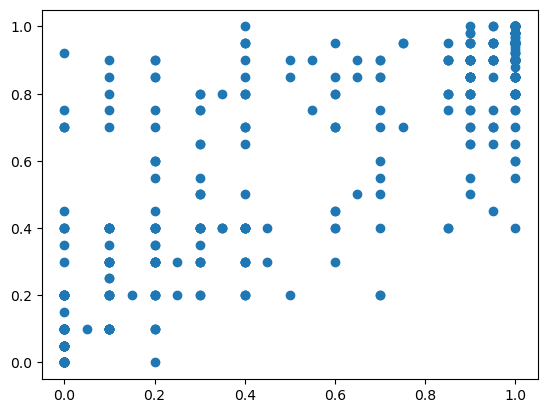

In [32]:
import matplotlib.pyplot as plt
plt.scatter(df["pro-score"].iloc[:500], df["flash-score"].iloc[:500])

In [33]:
df.to_csv("data_extension_sentiment.csv", index = False)